<a href="https://colab.research.google.com/github/lukasakar19-byte/Analisis-Regresi/blob/main/Projek_AnReg_Lukas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flowchart

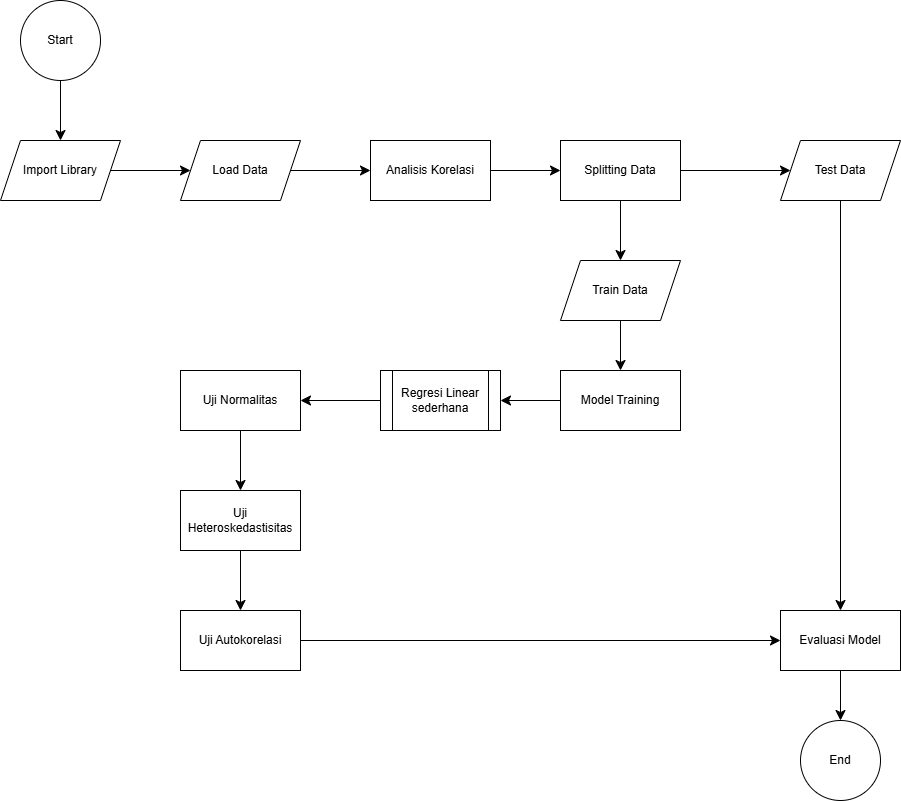

# Regresi Linear Sederhana

## Import Library

In [817]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

## Data

In [818]:
from google.colab import drive
drive.mount('/content/gdrive')
data = pd.read_csv("/content/gdrive/My Drive/MRA/Tugas/datania1k.csv")
data.info()

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1000 non-null   int64  
 1   Gender                1000 non-null   object 
 2   Age                   1000 non-null   int64  
 3   Driving_License       1000 non-null   int64  
 4   Region_Code           1000 non-null   float64
 5   Previously_Insured    1000 non-null   int64  
 6   Vehicle_Age           1000 non-null   object 
 7   Vehicle_Damage        1000 non-null   object 
 8   Annual_Premium        1000 non-null   float64
 9   Policy_Sales_Channel  1000 non-null   float64
 10  Vintage               1000 non-null   int64  
 11  Response              1000 non-null   int64  
dtypes: float64(3), int64(6), object(3)
memory us

In [836]:
data.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,100000,Male,22,1,8.0,0,< 1 Year,Yes,36513.0,160.0,189,0
1,100001,Male,24,1,36.0,0,< 1 Year,Yes,2630.0,160.0,268,0
2,100002,Female,22,1,15.0,0,< 1 Year,Yes,35832.0,152.0,289,0
3,100003,Male,72,1,28.0,0,> 2 Years,Yes,36685.0,26.0,113,0
4,100004,Male,66,1,28.0,0,> 2 Years,Yes,2630.0,45.0,123,1


In [820]:
data.tail()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
995,100995,Male,47,1,37.0,0,1-2 Year,Yes,29384.0,152.0,233,0
996,100996,Male,56,1,8.0,1,1-2 Year,No,47479.0,26.0,189,0
997,100997,Male,22,1,28.0,1,< 1 Year,No,29000.0,152.0,231,0
998,100998,Female,48,1,28.0,0,1-2 Year,Yes,45107.0,124.0,239,0
999,100999,Male,33,1,8.0,0,< 1 Year,Yes,43068.0,157.0,188,0


In [821]:
X = data[['Age']]
y = data['Annual_Premium']

# Combine X and Y into a new DataFrame
df = pd.concat([X, y], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1000 non-null   int64  
 1   Annual_Premium  1000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 15.8 KB


In [822]:
from scipy.stats import pearsonr

column_name = 'Age'
korelasi_pearson, p_value = pearsonr(X['Age'], y)
print(f"\nKoefisien Korelasi Pearson antara {column_name} dan Variabel Y: {korelasi_pearson:.3f}")


Koefisien Korelasi Pearson antara Age dan Variabel Y: 0.139


## Analisis Korelasi

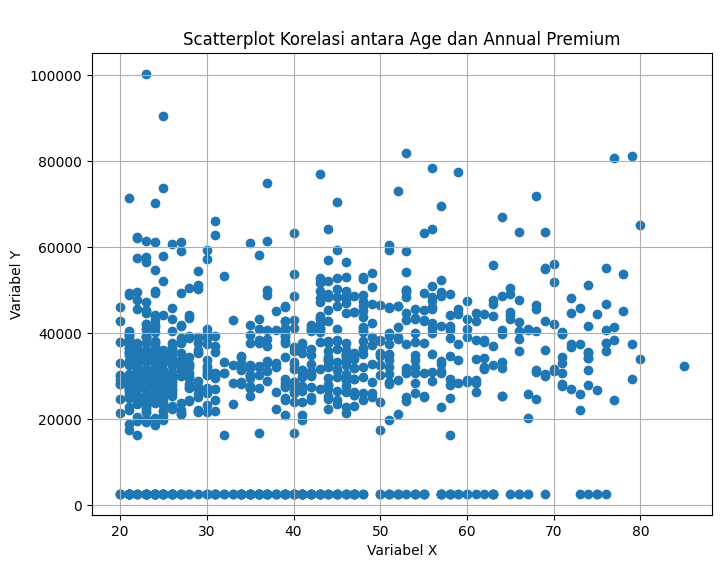

In [823]:
# Buat scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(X, y)
plt.xlabel('Variabel X')
plt.ylabel('Variabel Y')
plt.title(f'\nScatterplot Korelasi antara Age dan Annual Premium')
plt.grid(True)
# Tampilkan plot
plt.show()

In [824]:
korelasi_pearson, p_value = pearsonr(X['Age'], y)

# Tingkat signifikansi
alpha = 0.05

print(f"Koefisien Korelasi Pearson: {korelasi_pearson:.3f}")
print(f"P-value: {p_value:.5f}")
print(f"Tingkat Signifikansi (alpha): {alpha}")

# Uji hipotesis
if p_value < alpha:
    keputusan = "Tolak Hipotesis Nol (H0)"
    interpretasi_uji = "Ada hubungan linier yang signifikan antara Age dan Annual Premium."
else:
    keputusan = "Gagal Menolak Hipotesis Nol (H0)"
    interpretasi_uji = "Tidak ada hubungan linier yang signifikan antara Age dan Annual Premium."

print(f"\nKeputusan: {keputusan}")
print(f"Interpretasi Uji: {interpretasi_uji}")

Koefisien Korelasi Pearson: 0.139
P-value: 0.00001
Tingkat Signifikansi (alpha): 0.05

Keputusan: Tolak Hipotesis Nol (H0)
Interpretasi Uji: Ada hubungan linier yang signifikan antara Age dan Annual Premium.


## Split Data

In [825]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Membangun Model

In [826]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [827]:
coef_df = pd.DataFrame({
    'feature':['Vintage', 'Annual_Premium'],
    'coefficient':[model.intercept_, model.coef_[0]]
})
coef_df

,feature,coefficient
0,Vintage,25540.674335
1,Annual_Premium,114.798933


Persamaan Regresi:
Annual Premium = 25540,674335 + 114,798933 * Age

## Uji Asumsi

In [828]:
fitted = model.predict(X_train)
residual = y_train - fitted

### Uji Normalitas

In [829]:
from scipy import stats

# Calculate mean and standard deviation of residuals for the normal distribution reference
mean_residual = residual.mean()
std_residual = residual.std()

# Perform Kolmogorov-Smirnov test for normality
kolmogorov_test = stats.kstest(residual, 'norm', args=(mean_residual, std_residual))

print("Kolmogorov-Smirnov Test")
print("Statistic:", kolmogorov_test.statistic)
print("p-value:", kolmogorov_test.pvalue)

if p_value > 0.05:
    print("Keputusan: Residual terdistribusi normal")
else:
    print("Keputusan: Residual tidak normal")

Kolmogorov-Smirnov Test
Statistic: 0.11873487123176488
p-value: 2.7672657009006767e-10
Keputusan: Residual tidak normal


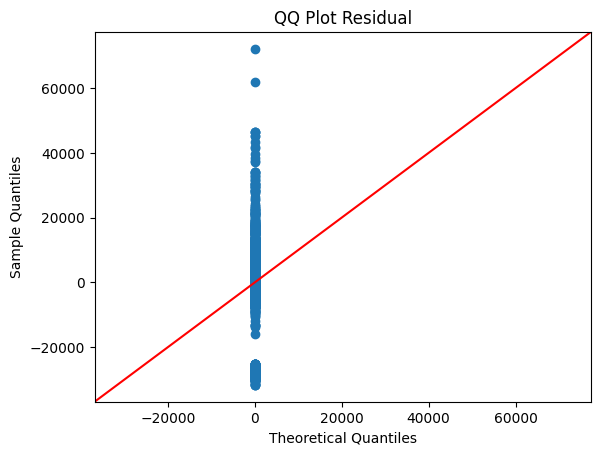

In [830]:
sm.qqplot(residual, line='45')
plt.title("QQ Plot Residual")
plt.show()

### Uji Heteroskedastisitas

In [831]:
from statsmodels.stats.api import het_breuschpagan

X_sm = sm.add_constant(X_train)
bp_test = het_breuschpagan(residual, X_sm)

p_value = float(bp_test[1])

print("Breusch-Pagan p-value:", p_value)

if p_value < 0.05:
    print("Keputusan: Heteroskedastisitas terdeteksi.")
else:
    print("Keputusan: Heteroskedastisitas tidak terdeteksi")

Breusch-Pagan p-value: 0.03380252419178734
Keputusan: Heteroskedastisitas terdeteksi.


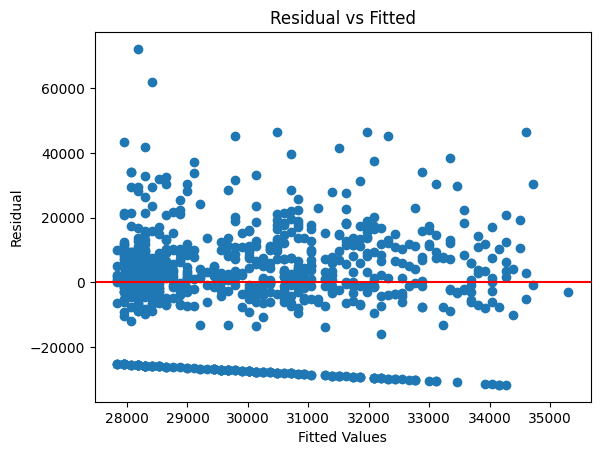

In [832]:
plt.scatter(fitted, residual)
plt.axhline(y=0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residual")
plt.title("Residual vs Fitted")
plt.show()

### Uji Autokorelasi

In [833]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residual)

print("Durbin Watson:", dw)
if 1.5 < dw < 2.5:
    print("Keputusan: Tidak terdapat autokorelasi.")
elif dw <= 1.5:
    print("Keputusan: Terdapat autokorelasi positif.")
else:
    print("Keputusan: Terdapat autokorelasi negatif.")

Durbin Watson: 2.0483567038827153
Keputusan: Tidak terdapat autokorelasi.


## Evaluasi Model

### Train

In [834]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_train_pred = model.predict(X_train)

r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

print("Train R2:", r2_train)
print("Train MAE:", mae_train)
print("Train RMSE:", rmse_train)

Train R2: 0.012420764036991883
Train MAE: 12002.298753000545
Train RMSE: 16312.812559015907


### Test

In [835]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_test_pred = model.predict(X_test)

r2_test = r2_score(y_test, y_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Test R2:", r2_test)
print("Test MAE:", mae_test)
print("Test RMSE:", rmse_test)

Test R2: 0.03707397753381614
Test MAE: 11794.924676955352
Test RMSE: 15692.339509952091


1. Nilai R2 antara data train dan data test  jauh, sehingga tidak mengalami overfitting

2. Nilai MAE antara data train dan data test tidak jauh, sehingga model bersifat stabil

3. Nilai RMSE antara data train dan data test tidak jauh, sehingga model bersifat stabil

# Kesimpulan Akhir

Performa model Linear Regression masih belum baik dalam menjelaskan variasi data, terlihat dari nilai R2 yang sangat kecil. Meskipun nilai MAE dan RMSE relatif kecil dan stabil antara data training dan testing, model masih memiliki kemampuan prediksi yang rendah.